# Crescent Visibility – Modeling Experiments

In this notebook, we experiment with different models to predict lunar crescent visibility.  
The goal is to explore model performance, evaluate metrics, and identify important predictors.

We focus on:
- Random Forest (main model)
- Optional: Logistic Regression or other baselines
- Feature importance analysis
- ROC / AUC evaluation

The final reproducible modeling pipeline is implemented in `src/models.py` and `src/evaluation.py`.


In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score


%matplotlib inline
sns.set_style("whitegrid")


## Load cleaned dataset

We use the processed CSV created by `data_processing.py`.


In [145]:
df = pd.read_csv(r"C:\Users\miled\OneDrive\Documents\GitHub\crescent-visibility-analysis\data\processed\cleaned_data.csv")
df.head()


,Lat,Long,ArcV,ArcL,DAZ,Crescent Width,MA,JD,Ele,Visibility,Lag_minutes
0,-7.97,111.50,-17.54,18.06,4.40,48.65,27.85,2458756.43,141.76,1,74.0
1,-7.57,110.83,-17.59,18.09,4.30,48.81,27.91,2458756.43,89.91,1,74.0
2,33.49,6.80,-12.24,12.31,1.29,20.22,-24.59,2459345.27,62.30,0,-65.0
3,32.67,51.67,-10.43,10.43,0.04,14.58,18.17,2456482.56,1575.56,1,56.0
4,48.14,11.58,-10.57,11.15,3.57,16.64,20.04,2456482.64,518.06,1,79.0


## Prepare features and target

In [146]:
X = df.drop(columns=["Visibility"])
y = df["Visibility"]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 5798
Testing samples: 1450


## Baseline model : Logistic Regression 
We train a simple logistic regression to establish a baseline 

In [147]:
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Metrics
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       590
           1       0.81      0.86      0.83       860

    accuracy                           0.79      1450
   macro avg       0.79      0.78      0.78      1450
weighted avg       0.79      0.79      0.79      1450



c:\Users\miled\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Confusion matrix

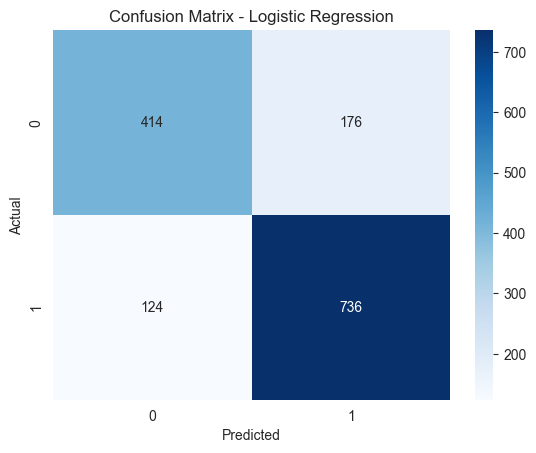

In [148]:

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## ROC Curve and AUC

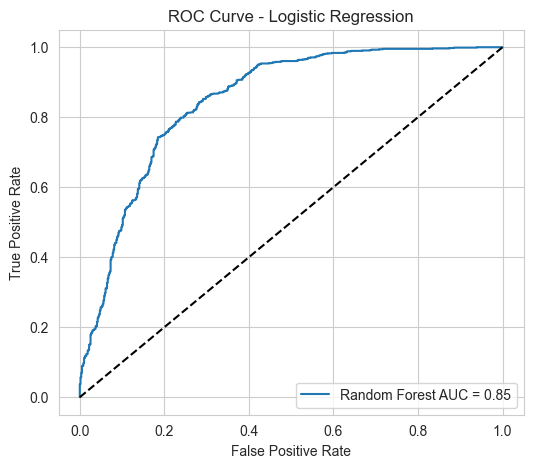

In [149]:
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_score_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'Random Forest AUC = {auc_score_lr:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## Random Forest Classifier 
Random Forest Classifier is robust , handles non-linear relationships, and does not require feature scaling.

In [150]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Classification report
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       590
           1       0.86      0.90      0.88       860

    accuracy                           0.85      1450
   macro avg       0.85      0.84      0.85      1450
weighted avg       0.85      0.85      0.85      1450



## Confusion matrix

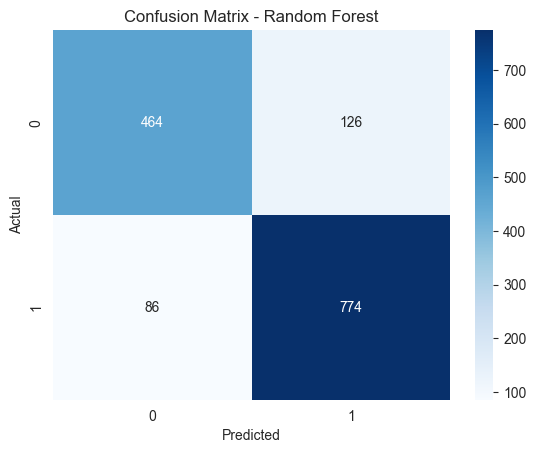

In [151]:

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Feature Importance 

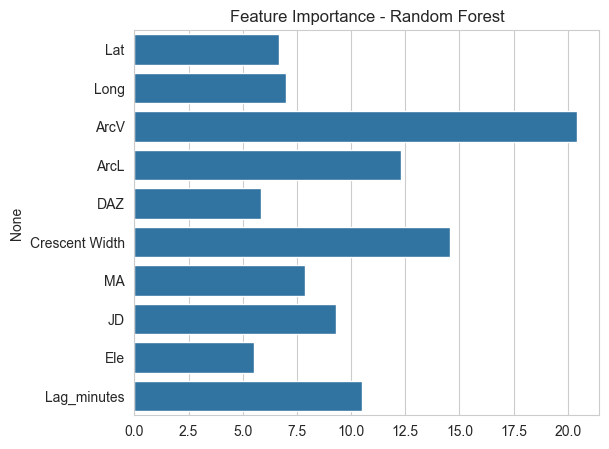

In [152]:
importances = rf_model.feature_importances_
features = X.columns

# Normalize to 100%
importances = 100 * importances / importances.sum()

plt.figure(figsize=(6,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.show()


## ROC Curve and AUC 

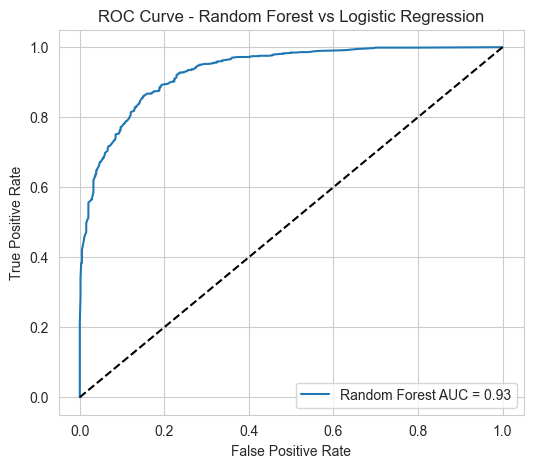

In [153]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest AUC = {auc_score:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest vs Logistic Regression")
plt.legend()
plt.show()

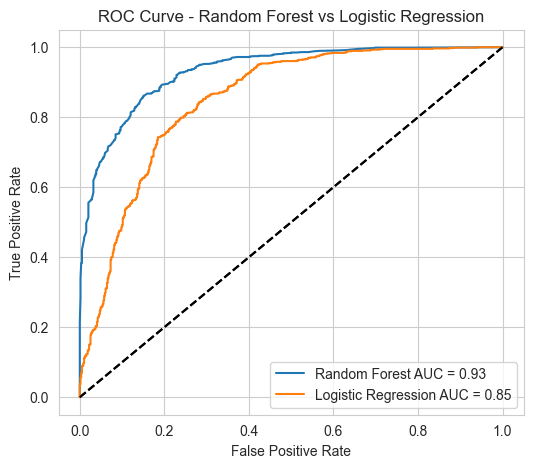

In [154]:

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_score_fr = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest AUC = {auc_score_fr:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression AUC = {auc_score_lr:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest vs Logistic Regression")
plt.legend()
plt.show()


## Bar plot comparison of metrics

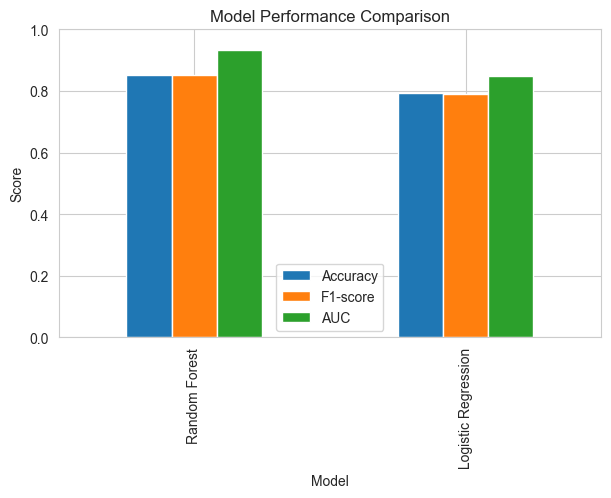

In [155]:
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)

auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
auc_lr = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [report_rf["accuracy"], report_lr["accuracy"]],
    "F1-score": [
        report_rf["weighted avg"]["f1-score"],
        report_lr["weighted avg"]["f1-score"]
    ],
    "AUC": [auc_rf, auc_lr]
})

comparison_df.set_index("Model").plot(kind="bar", figsize=(7,4))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.savefig(r"C:\Users\miled\OneDrive\Documents\GitHub\crescent-visibility-analysis\results\metrics\model_comparison.png", dpi=300)
plt.show()

## Model Comparison


Two models were evaluated :
- Logistic Regression
- Random Forest Classifier 

Evaluation metrics include :
- Accuracy
- F1-score
- ROC-AUC

Random Forest outperformed Logistic Regression, indicating the presence of non-linear relationships between crescent visibility features.